In [1]:

from mpl_toolkits.mplot3d import Axes3D
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from matplotlib.colors import LogNorm
import h5py
import argparse
import numpy as np
from os.path import exists
import seaborn as sns

from h5_util import SurfaceFileHandler as sfh


In [4]:


def plot_2d_contour(surf_file, surf_name='train_loss', vmin=0.1, vmax=10, vlevel=0.5, show=False):
    """Plot 2D contour map and 3D surface."""

    f = h5py.File(surf_file, 'r')
    x = np.array(f['xcoordinates'][:])
    y = np.array(f['ycoordinates'][:])
    X, Y = np.meshgrid(x, y)

    if surf_name in f.keys():
        Z = np.array(f[surf_name][:])
    elif surf_name == 'train_err' or surf_name == 'test_err' :
        Z = 100 - np.array(f[surf_name][:])
    else:
        print ('%s is not found in %s' % (surf_name, surf_file))

    print('\n------------------------------------------------------------------')
    print('plot_2d_contour')
    print('------------------------------------------------------------------')
    print("loading surface file: " + surf_file)
    print('len(xcoordinates): %d   len(ycoordinates): %d' % (len(x), len(y)))
    print('max(%s) = %f \t min(%s) = %f' % (surf_name, np.max(Z), surf_name, np.min(Z)))
    print(Z)

    if (len(x) <= 1 or len(y) <= 1):
        print('The length of coordinates is not enough for plotting contours')
        return

    # --------------------------------------------------------------------
    # Plot 2D contours
    # --------------------------------------------------------------------
    fig = plt.figure()
    CS = plt.contour(X, Y, Z, cmap='summer', levels=np.arange(vmin, vmax, vlevel))
    plt.clabel(CS, inline=1, fontsize=8)
    fig.savefig(surf_file + '_' + surf_name + '_2dcontour' + '.pdf', dpi=300,
                bbox_inches='tight', format='pdf')

    fig = plt.figure()
    print(surf_file + '_' + surf_name + '_2dcontourf' + '.pdf')
    CS = plt.contourf(X, Y, Z, cmap='summer', levels=np.arange(vmin, vmax, vlevel))
    fig.savefig(surf_file + '_' + surf_name + '_2dcontourf' + '.pdf', dpi=300,
                bbox_inches='tight', format='pdf')

    # --------------------------------------------------------------------
    # Plot 2D heatmaps
    # --------------------------------------------------------------------
    fig = plt.figure()
    sns_plot = sns.heatmap(Z, cmap='viridis', cbar=True, vmin=vmin, vmax=vmax,
                           xticklabels=False, yticklabels=False)
    sns_plot.invert_yaxis()
    sns_plot.get_figure().savefig(surf_file + '_' + surf_name + '_2dheat.pdf',
                                  dpi=300, bbox_inches='tight', format='pdf')

    # --------------------------------------------------------------------
    # Plot 3D surface
    # --------------------------------------------------------------------
    fig = plt.figure()
    ax = Axes3D(fig)
    surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm, linewidth=0, antialiased=False)
    fig.colorbar(surf, shrink=0.5, aspect=5)
    fig.savefig(surf_file + '_' + surf_name + '_3dsurface.pdf', dpi=300,
                bbox_inches='tight', format='pdf')

    f.close()
    if show: plt.show()


In [6]:
surf_file = 'Output/vox2_v1/17-01T01-38-13/surface_[-0.5,0.5,25]x[-0.5,0.5,25].h5'

f = h5py.File(surf_file, 'r')
x = np.array(f['xcoordinates'][:])
y = np.array(f['ycoordinates'][:])
X, Y = np.meshgrid(x, y)

Z = np.array(f['train_acc'][:])

<a list of 19 text.Text objects>

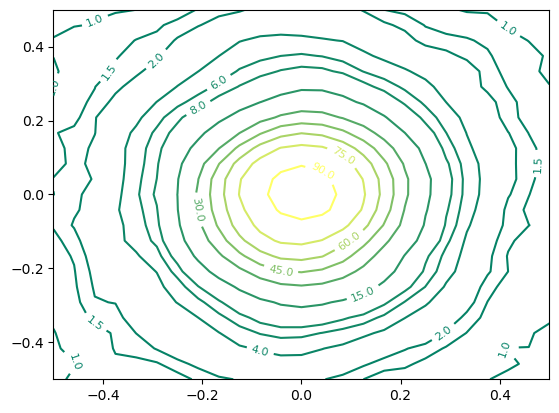

In [32]:

Z = np.array(f['train_acc'][:])

vmin=0
vmax=100
vlevel=10
show=False
levels=np.arange(vmin, vmax, vlevel)
levels = np.arange(0, 2, 0.5).tolist() + np.arange(2, 10, 2).tolist() + np.arange(15, 100, 15).tolist()
fig = plt.figure()
CS = plt.contour(X, Y, Z, cmap='summer', levels=levels)
plt.clabel(CS, inline=1, fontsize=8)
# plt.scatter(X.flatten(),Y.flatten(),marker=".")

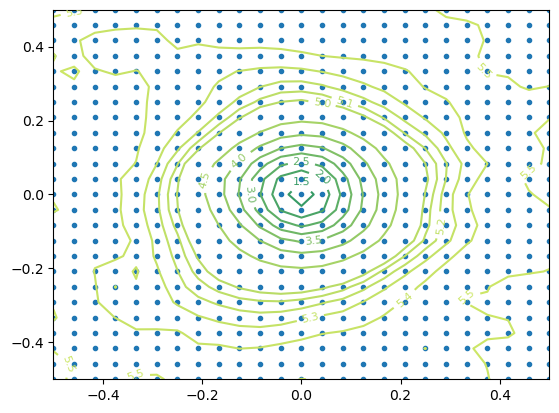

In [33]:

Z = np.array(f['train_loss'][:])

vmin=0
vmax=6
vlevel=0.5
show=False
levels=np.arange(0, 5, 0.5).tolist() + np.arange(5, 7, 0.1).tolist()
# levels = np.arange(0, 10, 2).tolist() + np.arange(15, 100, 15).tolist()
fig = plt.figure()
CS = plt.contour(X, Y, Z, cmap='summer', levels=levels)
plt.clabel(CS, inline=1, fontsize=8)
plt.scatter(X.flatten(),Y.flatten(),marker=".")

In [39]:
31

31

In [43]:
0.5/12*6

0.25

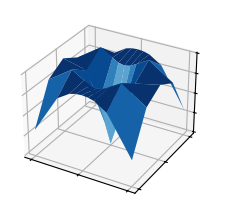

In [3]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib import cm

plt.style.use('_mpl-gallery')

# Make data
X = np.array([-2,-1,-0.5,-0.25,0.0,0.25,0.5,1,2])
Y = np.array([-2,-1,0.0,1,2])
X, Y = np.meshgrid(X, Y)
R = np.sqrt(X**2 + Y**2)
Z = np.sin(R)

# Plot the surface
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.plot_surface(X, Y, Z, vmin=Z.min() * 2, cmap=cm.Blues)

ax.set(xticklabels=[],
       yticklabels=[],
       zticklabels=[])

plt.show()

In [ ]:

# x = [1,3,2,1,5]
# y = [1,2,3,4,5]
# z = [1,2,1,2,1]

x = [1,2,3,1,2,3,1,2,3]
y = [1,1,1,2,2,2,3,3,3]
z = [1,2,3,4,5,6,7,8,9]

x = [2,1,2,3,1,1,2,3,3]
y = [1,2,2,2,1,3,3,1,3]
z = [2,4,5,6,1,7,8,3,9]



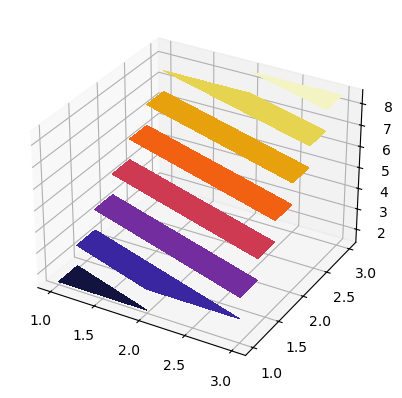

In [8]:
# Create a custom triangulation.

import matplotlib.tri as tri
triang = tri.Triangulation(x, y)

# Mask off unwanted triangles.


ax = plt.figure().add_subplot(projection='3d')
ax.tricontourf(triang, z, cmap=plt.cm.CMRmap)

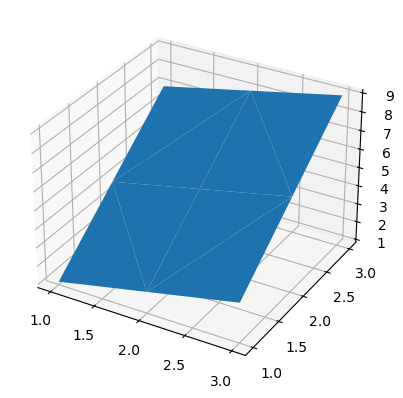

In [10]:


ax = plt.figure().add_subplot(projection='3d')
ax.plot_trisurf(triang,z)

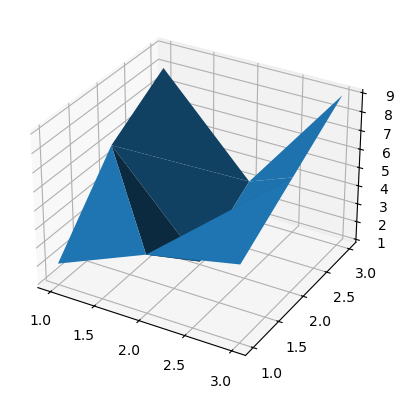

In [12]:


ax = plt.figure().add_subplot(projection='3d')
ax.plot_trisurf(triang,z)

In [17]:
def test(surf_file, detail_surf_file,surf_name="train_loss"): # Set to None if no detailed surface file is provided

    f = h5py.File(surf_file, 'r')
    x = np.array(f['xcoordinates'][:])
    y = np.array(f['ycoordinates'][:])

    print(f.keys())

    if surf_name in f.keys():
        Z = np.array(f[surf_name][:])
    elif surf_name == 'train_err' or surf_name == 'test_err' :
        Z = 100 - np.array(f[surf_name][:])
    else:
        print ('%s is not found in %s' % (surf_name, surf_file))

    # if a detailed surface file is provided, add its x, y coordinates and z values to the plot
    if detail_surf_file is not None:
        if not exists(detail_surf_file):
            print(f"Detail surface file {detail_surf_file} does not exist.")
            return
        detail_f = h5py.File(detail_surf_file, 'r')
        detail_x = np.array(detail_f['xcoordinates'][:])
        detail_y = np.array(detail_f['ycoordinates'][:])
        if surf_name in detail_f.keys():
            detail_Z = np.array(detail_f[surf_name][:])
        elif surf_name == 'train_err' or surf_name == 'test_err':
            detail_Z = 100 - np.array(detail_f[surf_name][:])
        else:
            print ('%s is not found in %s' % (surf_name, detail_surf_file))
            return
        
        # Combine the coordinates and values
        x_pointer_large = 0
        x_pointer_detail = 0
        y_pointer_large = 0
        y_pointer_detail = 0

        new_x = []
        new_y = []
        new_Z = []
        while y_pointer_large < len(y) and y_pointer_detail < len(detail_y):
            if y[y_pointer_large] < detail_y[y_pointer_detail]:
                x_pointer_large = 0
                while x_pointer_large < len(x):
                    new_y.append(y[y_pointer_large])
                    new_x.append(x[x_pointer_large])
                    new_Z.append(Z[y_pointer_large, x_pointer_large])
                    x_pointer_large += 1
                y_pointer_large += 1
                continue
            elif y[y_pointer_large] > detail_y[y_pointer_detail]:
                x_pointer_detail = 0
                while x_pointer_detail < len(detail_x):
                    new_y.append(detail_y[y_pointer_detail])
                    new_x.append(detail_x[x_pointer_detail])
                    new_Z.append(detail_Z[y_pointer_detail, x_pointer_detail])
                    x_pointer_detail += 1
                y_pointer_detail += 1
                continue 
            elif y[y_pointer_large] == detail_y[y_pointer_detail]:
                while x_pointer_large < len(x) and x_pointer_detail < len(detail_x):
                    new_y.append(detail_y[y_pointer_detail])
                    if x[x_pointer_large] < detail_x[x_pointer_detail]:
                        new_x.append(x[x_pointer_large])
                        new_Z.append(Z[y_pointer_large, x_pointer_large])
                        x_pointer_large += 1
                    elif x[x_pointer_large] > detail_x[x_pointer_detail]:
                        new_x.append(detail_x[x_pointer_detail])
                        new_Z.append(detail_Z[y_pointer_detail, x_pointer_detail])
                        x_pointer_detail += 1
                    else:
                        new_x.append(x[x_pointer_large])
                        new_Z.append(Z[y_pointer_large, x_pointer_large])
                        x_pointer_large += 1
                        x_pointer_detail += 1
                y_pointer_large += 1
                y_pointer_detail += 1
                continue
        
        while y_pointer_large < len(y) :
            x_pointer_large = 0
            while x_pointer_large < len(x):
                new_y.append(y[y_pointer_large])
                new_x.append(x[x_pointer_large])
                new_Z.append(Z[y_pointer_large, x_pointer_large])
                x_pointer_large += 1
            y_pointer_large += 1

        while y_pointer_detail < len(detail_y):
            x_pointer_detail = 0
            while x_pointer_detail < len(detail_x):
                new_y.append(detail_y[y_pointer_detail])
                new_x.append(detail_x[x_pointer_detail])
                new_Z.append(detail_Z[y_pointer_detail, x_pointer_detail])
                x_pointer_detail += 1
            y_pointer_detail += 1

        fig = plt.figure()
        ax = fig.add_subplot(projection='3d')
        surf = ax.plot_trisurf(new_x,new_y,new_Z,cmap=cm.coolwarm, linewidth=0, antialiased=False)
        fig.colorbar(surf, shrink=0.5, aspect=5)
        return fig

<KeysViewHDF5 ['dir_file', 'train_acc', 'train_loss', 'xcoordinates', 'ycoordinates']>


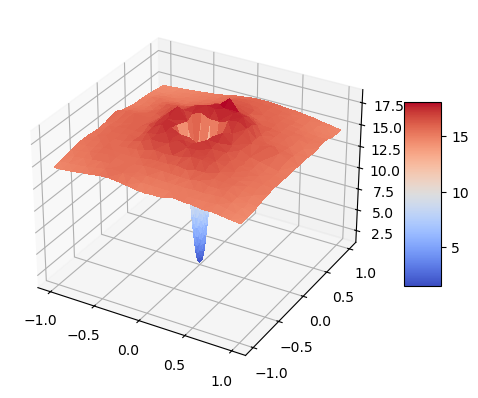

In [15]:

surf_file = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s/26-05T12-22-55/surface_[-1.0,1.0,21]x[-1.0,1.0,21].h5'
surf_name = 'train_loss'
detail_surf_file = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s/22-05T15-33-44/surface_[-0.1,0.1,21]x[-0.1,0.1,21].h5'
test(surf_file, detail_surf_file)

<KeysViewHDF5 ['dir_file', 'train_acc', 'train_loss', 'xcoordinates', 'ycoordinates']>


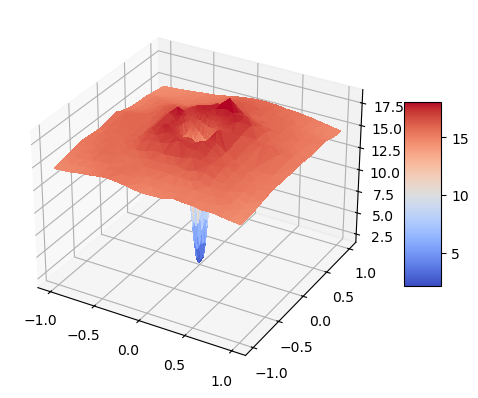

In [20]:
surf_file = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s/26-05T12-22-55/surface_[-1.0,1.0,21]x[-1.0,1.0,21].h5'
surf_name = 'train_loss'
# detail_surf_file = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s/22-05T15-33-44/surface_[-0.1,0.1,21]x[-0.1,0.1,21].h5'
detail_surf_file = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s/28-05T11-33-55/surface_[-0.25,0.25,21]x[-0.25,0.25,21].h5'
# surf_file = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s/26-05T12-22-55/11-06T21-12-57_extendby(6)/surface_[-1.60,1.60,33]x[-1.60,1.60,33].h5'
fig = test(surf_file, detail_surf_file)

fig.savefig('/mnt/ssd2/Tassi/TassiMA/loss-landscape/figures/res2net8s_3d_surface_small_1.pdf',)

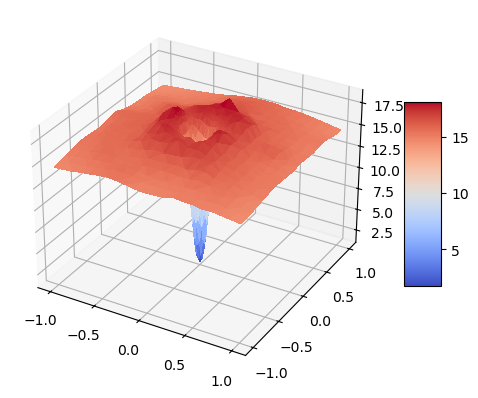

In [ ]:
surf_file2 = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s/28-05T11-33-55/surface_[-0.25,0.25,21]x[-0.25,0.25,21].h5'
surf_file =  '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s/26-05T12-22-55/surface_[-1.0,1.0,21]x[-1.0,1.0,21].h5'
surf_name = 'train_loss'

f = h5py.File(surf_file, 'r')
x = np.array(f['xcoordinates'][:])
y = np.array(f['ycoordinates'][:])
Z = np.array(f[surf_name][:])
X, Y = np.meshgrid(x, y)

f2 = h5py.File(surf_file2, 'r')
x2 = np.array(f2['xcoordinates'][:])
y2 = np.array(f2['ycoordinates'][:])
Z2 = np.array(f2[surf_name][:])
X2, Y2 = np.meshgrid(x2, y2)

new_x = X2.flatten().tolist() + X.flatten().tolist()
new_y = Y2.flatten().tolist() + Y.flatten().tolist()
new_Z = Z2.flatten().tolist() + Z.flatten().tolist()

surf_file3 = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s/22-05T15-33-44/surface_[-0.1,0.1,21]x[-0.1,0.1,21].h5'
f3 = h5py.File(surf_file3, 'r')
x3 = np.array(f3['xcoordinates'][:])
y3 = np.array(f3['ycoordinates'][:])
Z3 = np.array(f3[surf_name][:])
X3, Y3 = np.meshgrid(x3, y3)
new_x += X3.flatten().tolist()
new_y += Y3.flatten().tolist()
new_Z += Z3.flatten().tolist()

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
surf = ax.plot_trisurf(new_x,new_y,new_Z,cmap=cm.coolwarm, linewidth=0, antialiased=False)
fig.colorbar(surf, shrink=0.5, aspect=5)


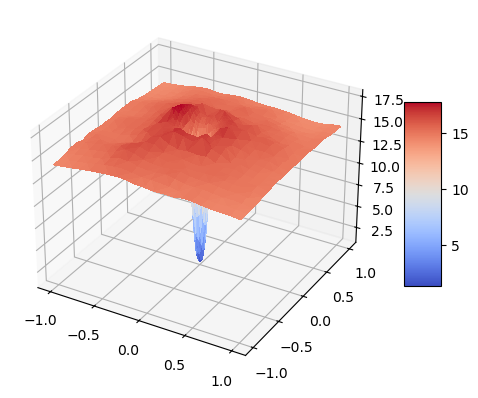

In [81]:
# # 8s
# surf_file2 = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s/28-05T11-33-55/surface_[-0.25,0.25,21]x[-0.25,0.25,21].h5'
# surf_file =  '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/resnext6g/23-05T11-14-20/surface_[-1.0,1.0,21]x[-1.0,1.0,21].h5'
# # surf_file = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s/26-05T12-22-55/11-06T21-12-57_extendby(6)/surface_[-1.60,1.60,33]x[-1.60,1.60,33].h5'
# # save_path = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/figures/res2net8s_3d_surface_big_1.5.pdf'
# save_path = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/figures/res2net8s_3d_surface.pdf'

# # 6g
# surf_file2 = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/resnext6g/28-05T00-33-21/surface_[-0.25,0.25,21]x[-0.25,0.25,21].h5'
# surf_file = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/resnext6g/23-05T11-14-20/31-05T02-01-36_increase_res(1)/surface_[-1.00,1.00,41]x[-1.00,1.00,41].h5'
# save_path = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/figures/resnext6g_3d_surface.pdf'

# 6s8g
surf_file2 = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/resnext6s8g/27-05T14-07-46_small/surface_[-0.25,0.25,21]x[-0.25,0.25,21].h5'
surf_file = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/resnext6s8g/25-05T17-09-03_large/surface_[-1.0,1.0,21]x[-1.0,1.0,21].h5'
save_path = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/figures/resnext6s8g_3d_surface.pdf'

# #v1
# surf_file2 = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/vox2_v1/17-01T01-38-13/surface_[-0.5,0.5,25]x[-0.5,0.5,25].h5'
# surf_file = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output
# save_path = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/figures/vox2_v1_3d_surface.pdf'

surf_name = 'train_loss'
f = h5py.File(surf_file, 'r')
x = np.array(f['xcoordinates'][:])
y = np.array(f['ycoordinates'][:])
Z = np.array(f[surf_name][:])
X, Y = np.meshgrid(x, y)

f2 = h5py.File(surf_file2, 'r')
x2 = np.array(f2['xcoordinates'][:])
y2 = np.array(f2['ycoordinates'][:])
Z2 = np.array(f2[surf_name][:])
X2, Y2 = np.meshgrid(x2, y2)

new_x = X2.flatten().tolist() + X.flatten().tolist()
new_y = Y2.flatten().tolist() + Y.flatten().tolist()
new_Z = Z2.flatten().tolist() + Z.flatten().tolist()

# surf_file3 = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s/22-05T15-33-44/surface_[-0.1,0.1,21]x[-0.1,0.1,21].h5'
# f3 = h5py.File(surf_file3, 'r')
# x3 = np.array(f3['xcoordinates'][:])
# y3 = np.array(f3['ycoordinates'][:])
# Z3 = np.array(f3[surf_name][:])
# X3, Y3 = np.meshgrid(x3, y3)
# new_x += X3.flatten().tolist()
# new_y += Y3.flatten().tolist()
# new_Z += Z3.flatten().tolist()

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
surf = ax.plot_trisurf(new_x,new_y,new_Z, linewidth=0, antialiased=False,cmap=cm.coolwarm,edgecolor='none') #,cmap=cm.coolwarm, cmap=cm.viridis_r
surf.set_rasterized(True)
fig.colorbar(surf, shrink=0.5, aspect=5)

fig.savefig(save_path,bbox_inches='tight', format='pdf')


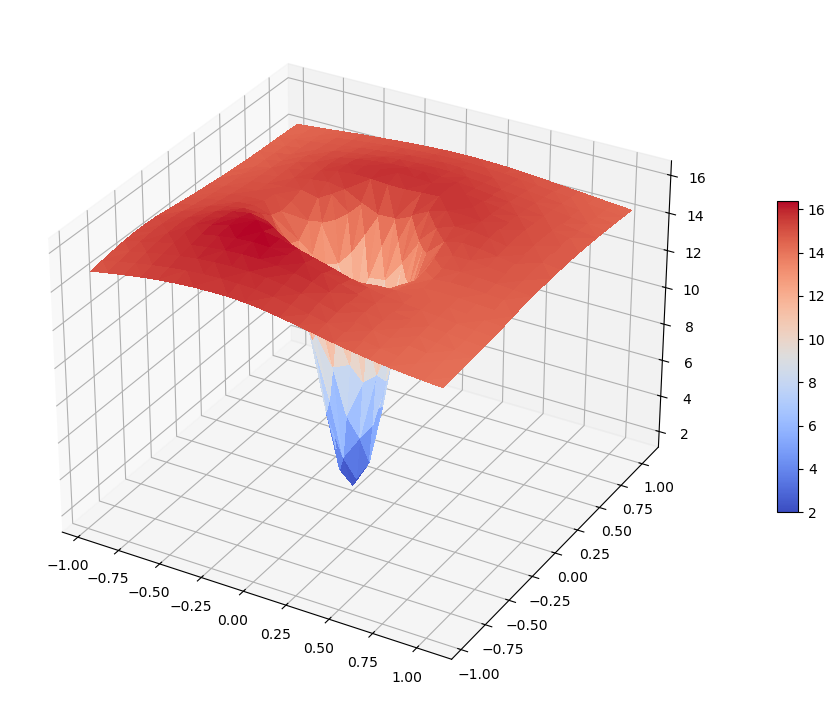

In [22]:
# # 8s
# surf_file2 = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s/28-05T11-33-55/surface_[-0.25,0.25,21]x[-0.25,0.25,21].h5'
# surf_file =  '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/resnext6g/23-05T11-14-20/surface_[-1.0,1.0,21]x[-1.0,1.0,21].h5'
# # surf_file = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s/26-05T12-22-55/11-06T21-12-57_extendby(6)/surface_[-1.60,1.60,33]x[-1.60,1.60,33].h5'
# # save_path = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/figures/res2net8s_3d_surface_big_1.5.pdf'
# save_path = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/figures/res2net8s_3d_surface.pdf'

# # 6g
# surf_file2 = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/resnext6g/28-05T00-33-21/surface_[-0.25,0.25,21]x[-0.25,0.25,21].h5'
# surf_file = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/resnext6g/23-05T11-14-20/31-05T02-01-36_increase_res(1)/surface_[-1.00,1.00,41]x[-1.00,1.00,41].h5'
# save_path = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/figures/resnext6g_3d_surface.pdf'

# # 6s8g
# surf_file2 = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/resnext6s8g/27-05T14-07-46_small/surface_[-0.25,0.25,21]x[-0.25,0.25,21].h5'
# surf_file = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/resnext6s8g/25-05T17-09-03_large/surface_[-1.0,1.0,21]x[-1.0,1.0,21].h5'
# save_path = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/figures/resnext6s8g_3d_surface.pdf'

# #v1
# surf_file2 = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/vox2_v1/17-01T01-38-13/surface_[-0.5,0.5,25]x[-0.5,0.5,25].h5'
# surf_file = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output
# save_path = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/figures/vox2_v1_3d_surface.pdf'

# 6s8g retrain
# surf_file = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/resnext6s8g_balancedTraining/18-06T02-15-09/surface_[-1.0,1.0,21]x[-1.0,1.0,21].h5'
# surf_file = "/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s_train/13-06T11-39-49/surface_[-0.95,1.05,21]x[-0.95,1.05,21].h5"

# 8s train
surf_file = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s_train/13-06T11-39-49/surface_[-0.95,1.05,21]x[-0.95,1.05,21].h5'
# surf_file2 = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s_train/18-06T10-40-57/surface_[-0.35,0.35,8]x[-0.35,0.35,8].h5'
# save_path = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/figures/resnext8s_TrainMode_3d_surface.pdf'



surf_name = 'train_loss'
f = h5py.File(surf_file, 'r')
x = np.array(f['xcoordinates'][:])
y = np.array(f['ycoordinates'][:])
Z = np.array(f[surf_name][:])
X, Y = np.meshgrid(x, y)

new_x = X.flatten().tolist()
new_y = Y.flatten().tolist() 
new_Z = Z.flatten().tolist() 


f2 = h5py.File(surf_file2, 'r')
x2 = np.array(f2['xcoordinates'][:])
y2 = np.array(f2['ycoordinates'][:])
Z2 = np.array(f2[surf_name][:])
X2, Y2 = np.meshgrid(x2, y2)
new_x += X2.flatten().tolist() 
new_y += Y2.flatten().tolist() 
new_Z += Z2.flatten().tolist() 

# surf_file3 = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s/22-05T15-33-44/surface_[-0.1,0.1,21]x[-0.1,0.1,21].h5'
# f3 = h5py.File(surf_file3, 'r')
# x3 = np.array(f3['xcoordinates'][:])
# y3 = np.array(f3['ycoordinates'][:])
# Z3 = np.array(f3[surf_name][:])
# X3, Y3 = np.meshgrid(x3, y3)
# new_x += X3.flatten().tolist()
# new_y += Y3.flatten().tolist()
# new_Z += Z3.flatten().tolist()

fig = plt.figure(figsize=(16,9)) # figsize=(4.8,3.6)
ax = fig.add_subplot(projection='3d')
surf = ax.plot_trisurf(new_x,new_y,new_Z, linewidth=0.00, antialiased=False,cmap=cm.coolwarm,edgecolor='grey') #,cmap=cm.coolwarm, cmap=cm.viridis_r
surf.set_rasterized(True)
fig.colorbar(surf, shrink=0.45, aspect=15,pad=0.06)

# fig.savefig(save_path,bbox_inches='tight', format='pdf')


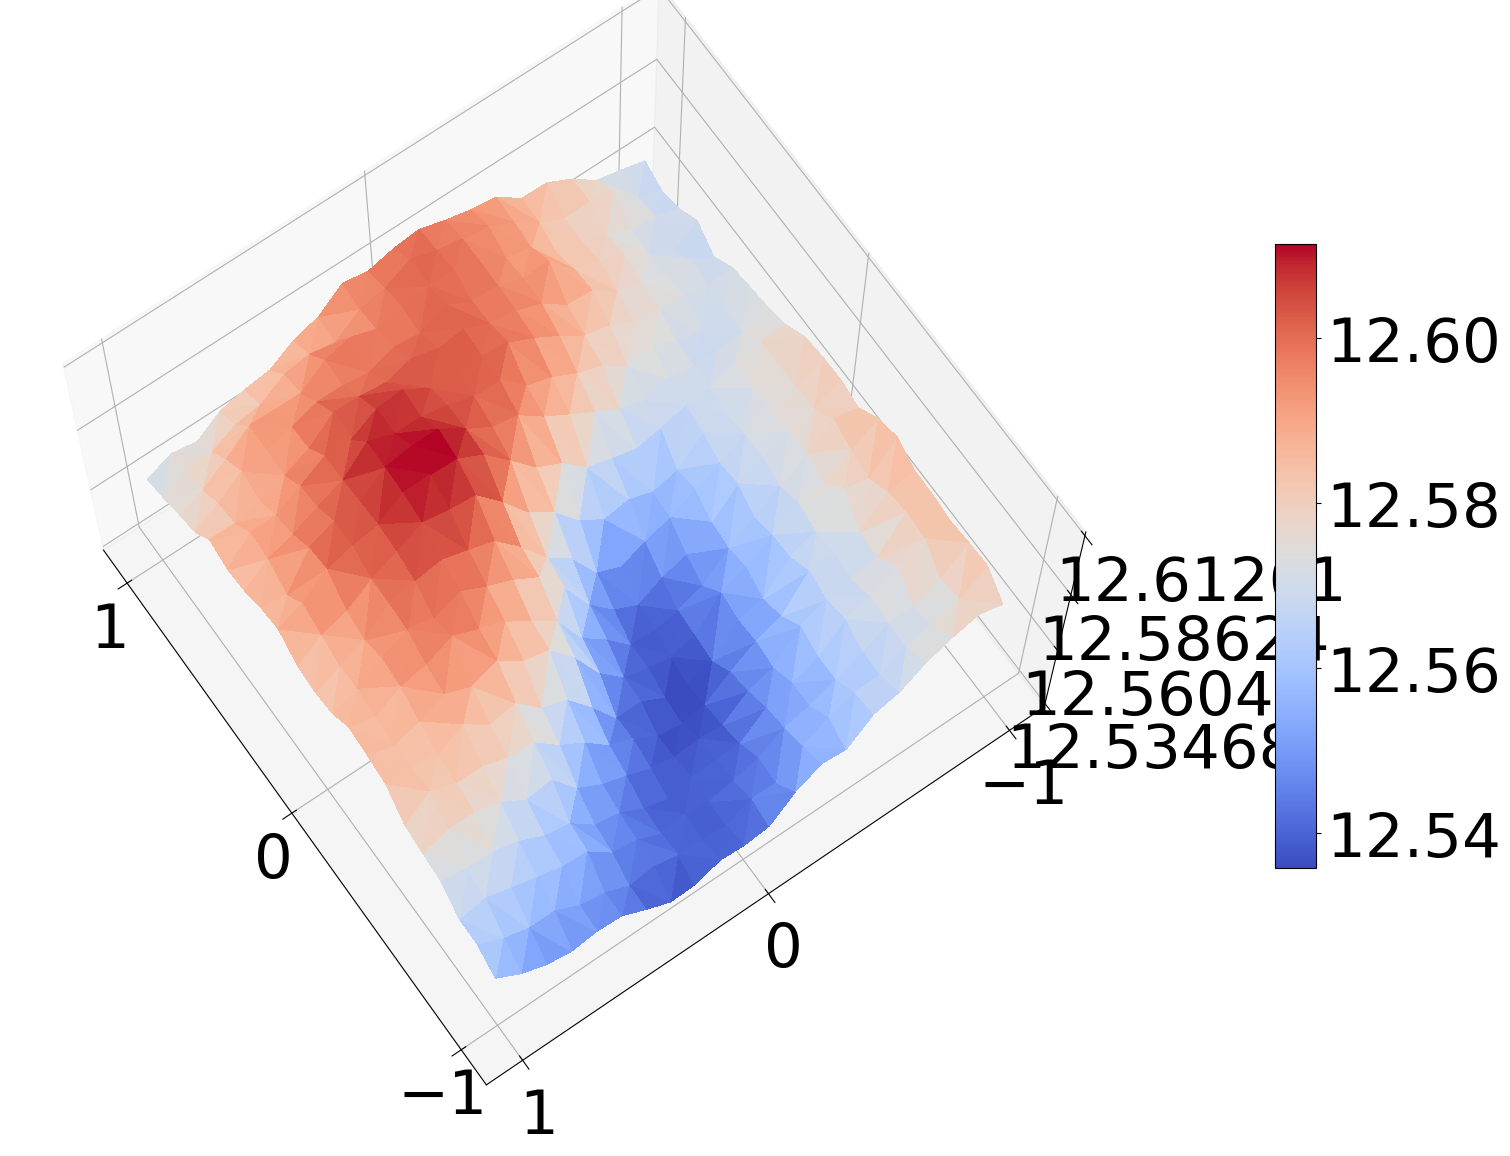

In [8]:
# # 8s
# surf_files = [
#     '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/resnext6g/23-05T11-14-20/surface_[-1.0,1.0,21]x[-1.0,1.0,21].h5',
#     '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s/28-05T11-33-55/surface_[-0.25,0.25,21]x[-0.25,0.25,21].h5'
# ]
# # surf_file = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s/26-05T12-22-55/11-06T21-12-57_extendby(6)/surface_[-1.60,1.60,33]x[-1.60,1.60,33].h5'
# # save_path = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/figures/res2net8s_3d_surface_big_1.5.pdf'
# save_path = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/figures/res2net8s_3d_surface.pdf'

# # 6g
# surf_files = [
#     '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/resnext6g/23-05T11-14-20/31-05T02-01-36_increase_res(1)/surface_[-1.00,1.00,41]x[-1.00,1.00,41].h5',
#     '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/resnext6g/28-05T00-33-21/surface_[-0.25,0.25,21]x[-0.25,0.25,21].h5'
# ]
# save_path = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/figures/resnext6g_3d_surface.pdf'

# # 6s8g 
# surf_files = [
#     '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/resnext6s8g/25-05T17-09-03_large/surface_[-1.0,1.0,21]x[-1.0,1.0,21].h5',
#     '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/resnext6s8g/27-05T14-07-46_small/surface_[-0.25,0.25,21]x[-0.25,0.25,21].h5'
# ]
# save_path = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/figures/resnext6s8g_3d_surface.pdf'

# # 6s8g - train
# surf_files = [
#     '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/resnext6s8g_train/18-06T20-09-05/surface_[-1.0,1.0,21]x[-1.0,1.0,21].h5',
#     '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/resnext6s8g_train/19-06T01-38-19/surface_[-0.35,0.35,8]x[-0.35,0.35,8].h5',
#     '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/resnext6s8g_train/19-06T01-59-37/surface_[-0.35,0.35,8]x[-0.3,0.3,7].h5',
#     '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/resnext6s8g_train/19-06T02-18-17/surface_[-0.3,0.3,7]x[-0.35,0.35,8].h5'
# ]
# save_path = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/figures/resnext6s8g_train_3d_surface.pdf'

# #v1
# surf_files = [
#     '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/vox2_v1/17-01T01-38-13/01-02T02-25-11/01-02T20-28-35/02-02T23-17-28/surface_[-1.13,1.13,55]x[-1.13,1.13,55].hdf5'
# ]
# save_path = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/figures/vox2_v1_3d_surface.pdf'

# # v2 -smproto2
# surf_files = [
#     "/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/vox2_v2_train/smproto2/14-06T15-03-53_extendby(5)/surface_[-1.50,1.50,31]x[-1.50,1.50,31].h5",
# ]
# save_path = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/figures/vox2_v2_smproto2_3d_surface.pdf'


# # v2 -smproto2
# surf_files = [
#     "/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/vox2_v2/smproto2/surface_[-1.0,1.0,21]x[-1.0,1.0,21].h5",
# ]
# save_path = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/figures/vox2_v2_smproto2_eval_3d_surface.pdf'

# # v2 -AAM
# surf_files = [
#     "/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/vox2_v2_AAMsoftmax/14-06T04-39-43_extendby(5)/surface_[-1.50,1.50,31]x[-1.50,1.50,31].h5",
# ]
# save_path = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/figures/vox2_v2_AAM_3d_surface.pdf'

# # v2 -SM ________------------____________ extend 5
# surf_files = [
#     "/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/vox2_v2_softmax/12-06T06-19-03/surface_[-1.0,1.0,21]x[-1.0,1.0,21].h5",
# ]
# save_path = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/figures/vox2_v2_SM_3d_surface.pdf'


# #_________________________________________________________________________
# # 6s8g retrain
# surf_files = [
#     '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/resnext6s8g_balancedTraining/18-06T02-15-09/surface_[-1.0,1.0,21]x[-1.0,1.0,21].h5',
#     "/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/resnext6s8g_balancedTraining/18-06T17-13-34/surface_[-0.35,0.35,8]x[-0.35,0.35,8].h5",
#     "/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/resnext6s8g_balancedTraining/18-06T18-02-50/surface_[-0.3,0.3,7]x[-0.35,0.35,8].h5",
#     "/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/resnext6s8g_balancedTraining/18-06T18-46-00/surface_[-0.35,0.35,8]x[-0.3,0.3,7].h5"

# ]
# save_path = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/figures/6s8g_retrained_3d_surface.pdf'
# #_________________________________________________________________________

# # bott
# surf_files = [
#     '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/resnet_bott/10-06T22-38-33/surface_[-1.0,1.0,21]x[-1.0,1.0,21].h5',
#     '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/resnet_bott/18-06T07-56-28/surface_[-0.25,0.25,17]x[-0.25,0.25,17].h5',
# ]
# save_path = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/figures/resbott_3d_surface.pdf'

# # 8s train
# surf_files = [
#     '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s_train/13-06T11-39-49/surface_[-0.95,1.05,21]x[-0.95,1.05,21].h5',
#     '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s_train/18-06T14-18-06/surface_[-0.3,0.3,7]x[-0.3,0.3,7].h5',
#     '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s_train/18-06T14-59-20/surface_[-0.3,0.3,7]x[-0.35,0.35,8].h5',
#     '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s_train/18-06T15-46-26/surface_[-0.35,0.35,8]x[-0.3,0.3,7].h5'
# ]
# # surf_file = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s_train/13-06T11-39-49/surface_[-0.95,1.05,21]x[-0.95,1.05,21].h5'
# # surf_file2 = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s_train/18-06T14-18-06/surface_[-0.3,0.3,7]x[-0.3,0.3,7].h5'
# # surf_file3 = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s_train/18-06T14-59-20/surface_[-0.3,0.3,7]x[-0.35,0.35,8].h5'
# # surf_file4 = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s_train/18-06T15-46-26/surface_[-0.35,0.35,8]x[-0.3,0.3,7].h5'
# save_path = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/figures/8s_train.pdf'

surf_files = [
    '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/vox2_v2_random_train/18-06T22-58-25/surface_[-1.0,1.0,21]x[-1.0,1.0,21].h5'
]
save_path = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/figures/vox2_v2_random_train_3d_surface.pdf'

surf_name = 'train_loss'

new_x = []
new_y = []
new_Z = []

for surf_file in surf_files:
    f = h5py.File(surf_file, 'r')
    x = np.array(f['xcoordinates'][:])
    y = np.array(f['ycoordinates'][:])
    Z = np.array(f[surf_name][:])
    X, Y = np.meshgrid(x, y)

    new_x += X.flatten().tolist()
    new_y += Y.flatten().tolist() 
    new_Z += Z.flatten().tolist() 
    f.close()

# figsize = (16,9) 
# figsize = (4.8,3.6)
figsize= (19.2,18)
labelsize = 44
fig = plt.figure(figsize=figsize) # figsize=(4.8,3.6)
ax = fig.add_subplot(projection='3d')
surf = ax.plot_trisurf(new_x,new_y,new_Z, linewidth=0.00, antialiased=False,cmap=cm.coolwarm,edgecolor='grey') #,cmap=cm.coolwarm, cmap=cm.viridis_r
surf.set_rasterized(True)
cbar = fig.colorbar(surf, shrink=0.45, aspect=15,pad=0.115)
cbar.ax.tick_params(labelsize=labelsize)

# Set ticks on all axes
tick_values = [-1, 0, 1]
ax.set_xticks(tick_values)
ax.set_yticks(tick_values)
# Set dynamic Z-axis ticks
z_min, z_max = np.min(new_Z), np.max(new_Z)
z_ticks = np.linspace(z_min, z_max, 4)
ax.zaxis.set_tick_params(pad=38)
ax.xaxis.set_tick_params(pad=6)
ax.yaxis.set_tick_params(pad=8)
ax.set_zticks(z_ticks)

# cbar.ax.yaxis.offsetText.set_fontsize(labelsize)
# ax.zaxis.offsetText.set_fontsize(0)

# Increase font sizes
ax.tick_params(axis='both', which='major', labelsize=labelsize)

ax.view_init(elev=70, azim=145)

# fig.savefig(save_path,bbox_inches='tight', format='pdf')


In [23]:
# 8s train
surf_file = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s_train/13-06T11-39-49/surface_[-0.95,1.05,21]x[-0.95,1.05,21].h5'
surf_file2 = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s_train/18-06T10-40-57/surface_[-0.35,0.35,8]x[-0.35,0.35,8].h5'
surf_file3 = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s_train/18-06T14-18-06/surface_[-0.3,0.3,7]x[-0.3,0.3,7].h5'
surf_file4 = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s_train/18-06T14-59-20/surface_[-0.3,0.3,7]x[-0.35,0.35,8].h5'
surf_file5 = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s_train/18-06T15-46-26/surface_[-0.35,0.35,8]x[-0.3,0.3,7].h5'

In [3]:
s='/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/vox2_v2/smproto2/surface_[-1.0,1.0,21]x[-1.0,1.0,21].h5'

In [26]:
# s1 = sfh(surf_file)
s1 = sfh(surf_file)
s2 = sfh(surf_file2)
s3 = sfh(surf_file3)
s4 = sfh(surf_file4)
s5 = sfh(surf_file5)

In [28]:
print(s1.getCoordinates())
print(s2.getCoordinates())
print(s3.getCoordinates())
print(s4.getCoordinates())
print(s5.getCoordinates())

{'x': array([-0.95, -0.85, -0.75, -0.65, -0.55, -0.45, -0.35, -0.25, -0.15,
       -0.05,  0.05,  0.15,  0.25,  0.35,  0.45,  0.55,  0.65,  0.75,
        0.85,  0.95,  1.05]), 'y': array([-0.95, -0.85, -0.75, -0.65, -0.55, -0.45, -0.35, -0.25, -0.15,
       -0.05,  0.05,  0.15,  0.25,  0.35,  0.45,  0.55,  0.65,  0.75,
        0.85,  0.95,  1.05])}
{'x': array([-0.35, -0.25, -0.15, -0.05,  0.05,  0.15,  0.25,  0.35]), 'y': array([-0.35, -0.25, -0.15, -0.05,  0.05,  0.15,  0.25,  0.35])}
{'x': array([-0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3]), 'y': array([-0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3])}
{'x': array([-0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3]), 'y': array([-0.35, -0.25, -0.15, -0.05,  0.05,  0.15,  0.25,  0.35])}
{'x': array([-0.35, -0.25, -0.15, -0.05,  0.05,  0.15,  0.25,  0.35]), 'y': array([-0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3])}


In [41]:
res2net8s = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s/22-05T13-42-12/surface_[-1.0,1.0,21]x[-1.0,1.0,21].h5'
resnext6g = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/resnext6g/23-05T11-14-20/surface_[-1.0,1.0,21]x[-1.0,1.0,21].h5' #'/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/resnext6g/23-05T11-14-20/31-05T02-01-36_increase_res(1)/surface_[-1.00,1.00,41]x[-1.00,1.00,41].h5'
resnext6s8g = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/resnext6s8g/25-05T17-09-03_large/surface_[-1.0,1.0,21]x[-1.0,1.0,21].h5'
v1 =  '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/vox2_v1/17-01T01-38-13/01-02T02-25-11/01-02T20-28-35/02-02T23-17-28/surface_[-1.13,1.13,55]x[-1.13,1.13,55].hdf5'
res = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/resnet_bott/10-06T22-38-33/surface_[-1.0,1.0,21]x[-1.0,1.0,21].h5'

v2 = "/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/vox2_v2_train/smproto2/14-06T15-03-53_extendby(5)/surface_[-1.50,1.50,31]x[-1.50,1.50,31].h5"
res_6s8g_retrained =  '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/resnext6s8g_balancedTraining/18-06T02-15-09/surface_[-1.0,1.0,21]x[-1.0,1.0,21].h5'
res2net8s_train = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s_train/13-06T11-39-49/surface_[-0.95,1.05,21]x[-0.95,1.05,21].h5'
resnext6s8g_train = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/resnext6s8g_train/18-06T20-09-05/surface_[-1.0,1.0,21]x[-1.0,1.0,21].h5'

In [34]:
from scipy.interpolate import interp1d

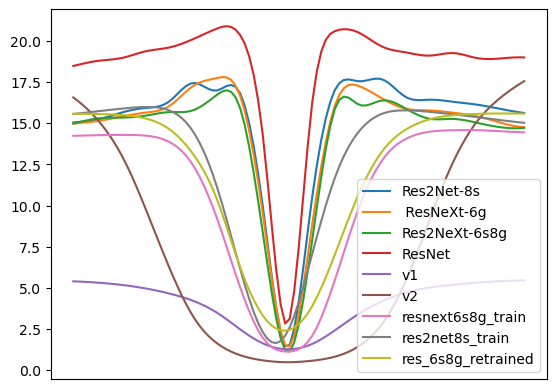

In [51]:
offset = [0,-10,-28,0,0]
plt.figure()
# plt.title(names[idx])
# names = ['ResNet','Res2Net-8s', ' ResNeXt-6g','Res2NeXt-6s8g']
names = ['Res2Net-8s', ' ResNeXt-6g','Res2NeXt-6s8g','ResNet',"v1","v2","resnext6s8g_train","res2net8s_train","res_6s8g_retrained"]

k = [res2net8s,resnext6g,resnext6s8g,res,v1,v2,resnext6s8g_train,res2net8s_train,res_6s8g_retrained]
for i in range(len(k)):
    s = k[i]
    # Create interpolator

    D = sfh(s).getTrainLoss()
    xs,ys = D.shape
    x = D[:,ys//2]
    
    f_interp = interp1d(np.linspace(-len(x)//2,len(x)//2,len(x)), x, kind='cubic')  # or 'linear'

    # Create new x values for smoother plotting
    x_fine = np.linspace(-10, 10, 101)
    y_fine = f_interp(x_fine)
    # plt.plot(x,label=names[idx])
    plt.plot(x_fine,y_fine,label=names[i])
plt.legend()
plt.xticks([])
plt.savefig('/mnt/ssd2/Tassi/TassiMA/loss-landscape/figures/1D.pdf',bbox_inches='tight',format='pdf')

In [47]:
x

array([14.79331281, 15.06061851, 15.24219084, 15.65607892, 15.93303566,
       16.32253838, 17.45196788, 16.99053687, 16.83457351,  9.51310867,
        1.368807  , 10.03506258, 17.01755181, 17.55639302, 17.67545206,
       16.59709066, 16.43647596, 16.30888736, 16.13737409, 15.87689235,
       15.6315082 ])

([], [])

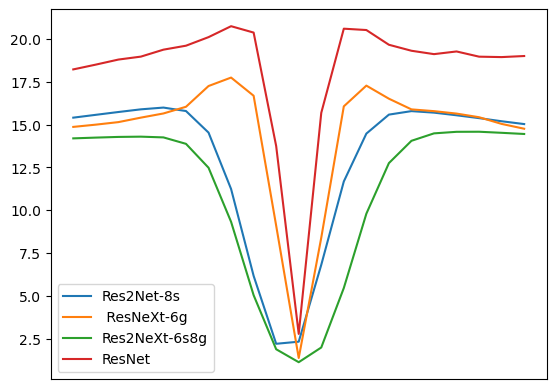

In [ ]:
# offset = [0,-10,-28,0,0]
# plt.figure()
# # plt.title(names[idx])
# names = ['Res2Net-8s', ' ResNeXt-6g', 'Res2NeXt-6s8g', 'ResNet']
# for idx,s in enumerate([res2net8s,resnext6g,resnext6s8g,res]):
    
#     # Create interpolator
#     f_interp = interp1d(np.linspace(-10,10,21), x, kind='cubic')  # or 'linear'

#     # Create new x values for smoother plotting
#     x_fine = np.linspace(-10, 10, 101)
#     y_fine = f_interp(x_fine)

#     D = sfh(s).getTrainLoss()
#     xs,ys = D.shape
#     x = D[:,ys//2]
#     plt.plot(x,label=names[idx])
#     # plt.plot(x_fine,y_fine)
# plt.legend()
# plt.xticks([])

s2.getCoordinates()

(<Figure size 1300x500 with 4 Axes>,
 (<Axes: title={'center': 'Train Loss'}, xlabel='x', ylabel='y'>,
  <Axes: title={'center': 'Train Acc'}, xlabel='x', ylabel='y'>))

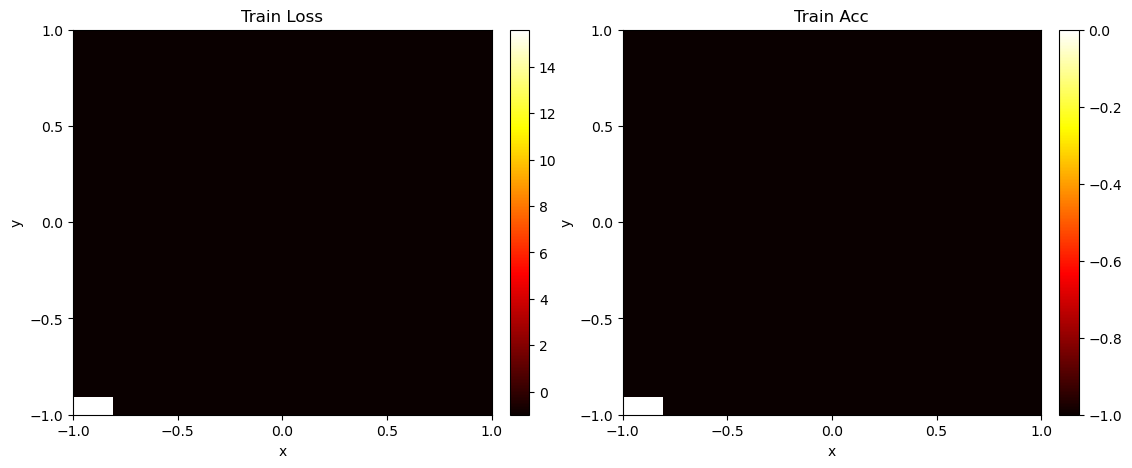

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# Create interpolator
f_interp = interp1d(np.linspace(-10,10,21), x, kind='cubic')  # or 'linear'

# Create new x values for smoother plotting
x_fine = np.linspace(x.min(), x.max(), 300)
y_fine = f_interp(x_fine)

# Plot
plt.plot(x, y, 'o', label='Original Points')
plt.plot(x_fine, y_fine, '-', label='Interpolated Curve')
plt.legend()
plt.grid(True)
plt.show()

In [37]:
3.6*5

18.0

In [6]:
np.linspace(-0.3,0.3,7)

array([-0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3])

In [10]:
np.linspace(-0.35,0.35,8)

array([-0.35, -0.25, -0.15, -0.05,  0.05,  0.15,  0.25,  0.35])